# Exoplanet Analysis Tools — 01: Getting started

Welcome! This notebook series introduces the **Exoplanet Analysis Tools** package through a
real-life example: the characterization of the hot super-Neptune **TOI-3568 b**
([Martioli et al. 2024, A&A 691, A312](https://ui.adsabs.harvard.edu/abs/2024A%26A...691A.312M/abstract)),
using the actual TESS photometry and MAROON-X + SPIRou radial velocities from the paper.

**The notebook series:**

| # | Notebook | Contents |
|---|----------|----------|
| 01 | Getting started | Package tour, priors files, system parameters in JSON, transit & RV models |
| 02 | TESS photometry | Loading light curves, selecting transits, MCMC transit fit |
| 03 | Radial velocities | Loading RVs, GLS periodogram, MCMC orbit fit |
| 04 | Joint fit | Joint transit+RV MCMC fit, derived physical parameters |

**Installation** (from the repository root): `pip install -U .`

## 1. Package overview

The package is organized into library modules (importable) and command-line tools.
Submodules are loaded lazily, so importing the package is instantaneous.

In [1]:
import exoplanet_analysis
print("version:", exoplanet_analysis.__version__)
print(exoplanet_analysis.__doc__)

version: 1.1.0

Exoplanet Analysis Tools

A toolkit for the joint analysis of radial velocity (RV) and photometry data
to obtain the best-fit orbital and physical parameters of exoplanets.

Library modules
---------------
- ``exoplanetlib``   : transit and RV models (batman-based) and Keplerian orbits
- ``priorslib``      : priors and posteriors I/O and handling
- ``fitlib``         : optimization and MCMC (emcee) fitting engine
- ``gp_lib``         : Gaussian Process utilities (george / celerite)
- ``rvutils``        : radial velocity utilities and periodograms
- ``timeseries_lib`` : time series analysis utilities
- ``tess``           : TESS data access (MAST), light curves and limb darkening
- ``systemlib``      : planetary system parameters I/O in JSON format

Command-line tools are installed alongside this package; see the README
or run any of them with ``-h`` (e.g. ``transit_fit -h``, ``rv_fit -h``,
``transit_rv_fit -h``).

@author: Eder Martioli



In [2]:
%matplotlib inline
# The modules we will use throughout this series
import numpy as np
import matplotlib.pyplot as plt
from exoplanet_analysis import priorslib, exoplanetlib, fitlib, systemlib

# every function is documented -- try help() on anything:
help(fitlib.bin_data)

Help on function bin_data in module exoplanet_analysis.fitlib:

bin_data(x, y, yerr, median=False, binsize=0.005, min_npoints=1)
    Bin a time series into regular time bins, propagating uncertainties.

    Parameters
    ----------
    x
        Array of x values.
    y
        Array of y values.
    yerr
        Array of y uncertainties.
    median : bool, optional (default: False)
        Use the median instead of the weighted mean.
    binsize : float, optional (default: 0.005)
        Bin size in time units [d].
    min_npoints : int, optional (default: 1)



## 2. Priors files (`.pars`)

The fitting routines are driven by a **priors file** defining one parameter per line:
`Parameter_ID  Prior_Type  Values`. Supported prior types are `FIXED`,
`Normal` (mu,sigma), `Normal_positive`, `Uniform` (min,max,start) and `Jeffreys` (min,max,start).

Per-planet parameters carry a 3-digit planet index suffix (e.g. `per_000`), and include:
`tc` (transit time, BJD), `per` (period, d), `a` (a/R*), `rp` (Rp/R*), `inc` (deg) or `b`,
`u0`,`u1` (quadratic limb darkening), `esinw`,`ecosw` (or legacy `ecc`,`w`),
`k` (RV semi-amplitude), `rvsys`, `trend`, `quadtrend`. Star-level: `teff`, `ms`, `rs`,
optional `rhos`, and `n_planets`.

Below is the actual priors file used for TOI-3568 b in Martioli et al. (2024):

In [3]:
priors_file = "data/TOI-3568/TOI-3568.pars"
print(open(priors_file).read())

# Parameter_ID	Prior_Type	Values
teff	FIXED	4960,49
ms	FIXED	0.776,0.021
rs	FIXED	0.719,0.013
#rhos    Normal  2.0918557830,0.5357928035
n_planets	FIXED	1
transit_000	FIXED	1
k_000	Uniform	-1000,1000,12.0213119413
tc_000	Uniform	2459799,2459800,2459799.3828418534
a_000	Uniform	10,20,13.5328445553
per_000	Uniform	4.415,4.420,4.4178490108
inc_000	Uniform	85,91,89.5230363203
#b_000   Uniform  0,1,0.0354017342
rp_000	Uniform	0,1,0.0762261965
#ecc_000	Uniform	0,1,0.000001
#w_000	Uniform	0,360,90
ecc_000	FIXED	0
w_000	FIXED	90
u0_000	Uniform	0.1,1,0.3387441639
u1_000	Uniform	0,1,0.3080111186
rvsys_000	FIXED	0.0
trend_000	FIXED	0.0
quadtrend_000	FIXED	0.



In [4]:
# priorslib.read_priors parses it into a dictionary of prior objects
priors = priorslib.read_priors(priors_file)

free = [k for k in priors if isinstance(priors[k], dict) and priors[k].get("type") not in (None, "FIXED")
        and not k.endswith("_err") and not k.endswith("_pdf")]
print("free parameters:", free)
print("\nexample -- per_000:", priors["per_000"]["type"], "| start value:", priors["per_000"]["object"].value)

free parameters: ['k_000', 'tc_000', 'a_000', 'per_000', 'inc_000', 'rp_000', 'u0_000', 'u1_000']

example -- per_000: Uniform | start value: 4.4178490108


## 3. System parameters in JSON

The package also supports a **system parameters JSON format** that describes the full
system (star + planets) and works both as priors *input* and posteriors *output* for
every module. It supports all system parameters, even those not determined by the fits.
A blank template with every supported field can be created with one call
(or with the `system_params` command-line tool):

In [5]:
system = systemlib.create_template(n_planets=1, system_name="TOI-3568")
print("components:", system["components"])
print("planet block keys:", [k for k in system["planet b"] if not k.startswith("_")])

components: ['star A', 'planet b']
planet block keys: ['name', 'object_type', 'transit', 'radius_rstar', 'radius_jupiter', 'radius_earth', 'mass_jupiter', 'mass_earth', 'density_cgs', 'surface_gravity', 'orbital_sma_rstar', 'orbital_sma_au', 'orbital_period_days', 'orbital_ecc', 'orbital_omega', 'orbital_Omega', 'orbital_inc', 'impact_parameter', 'esinw', 'ecosw', 'spinorbit_obliquity', 'rv_semi_amplitude', 'systemic_velocity', 'rv_linear_trend', 'rv_quadratic_trend', 'transit_time_bjd', 'time_of_periastron_bjd', 'transit_depth', 'transit_duration_hours', 'limb_darkening_coeffs', 'equilibrium_temperature', 'insolation_earth', 'transmission_spectrum_ref']


In [6]:
# Fill the template with the TOI-3568 parameters from Martioli et al. (2024).
# Format: [value, 1-sigma]. error=None -> FIXED; error>0 -> Normal prior (fittable parameters).
# For full control use {"value":..., "error":..., "prior":"Uniform", "min":..., "max":...}.
star = system["star A"]
star["teff"]   = [4960.0, 49.0]
star["mass"]   = [0.776, 0.021]
star["radius"] = [0.719, 0.013]
star["limb_darkening_coeffs"] = [
    {"value": 0.3387, "prior": "Uniform", "min": 0.1, "max": 1.0},
    {"value": 0.3080, "prior": "Uniform", "min": 0.0, "max": 1.0},
]

planet = system["planet b"]
planet["name"] = "TOI-3568 b"
planet["orbital_period_days"] = {"value": 4.4178490108, "prior": "Uniform", "min": 4.415, "max": 4.420}
planet["transit_time_bjd"]    = {"value": 2459799.3828418534, "prior": "Uniform", "min": 2459799.0, "max": 2459800.0}
planet["orbital_sma_rstar"]   = {"value": 13.5328445553, "prior": "Uniform", "min": 10.0, "max": 20.0}
planet["radius_rstar"]        = {"value": 0.0762261965, "prior": "Uniform", "min": 0.0, "max": 1.0}
planet["orbital_inc"]         = {"value": 89.5230363203, "prior": "Uniform", "min": 85.0, "max": 91.0}
planet["rv_semi_amplitude"]   = {"value": 12.0213119413, "prior": "Uniform", "min": -1000.0, "max": 1000.0}
planet["orbital_ecc"]         = [0.0, None]   # circular orbit (FIXED)
planet["orbital_omega"]       = [90.0, None]

import os
os.makedirs("outputs", exist_ok=True)
systemlib.save_system(system, "outputs/TOI-3568_system.json")
print("saved outputs/TOI-3568_system.json")

saved outputs/TOI-3568_system.json


In [7]:
# The JSON converts transparently into the internal priors representation -- so a
# system JSON file can be passed anywhere a .pars priors file is accepted:
print("".join(systemlib.system_to_pars_lines(system)))

# Parameter_ID	Prior_Type	Values
teff	FIXED	4960
ms	FIXED	0.776
rs	FIXED	0.719
n_planets	FIXED	1
transit_000	FIXED	1
per_000	Uniform	4.415,4.42,4.4178490108
tc_000	Uniform	2459799,2459800,2459799.38284185
a_000	Uniform	10,20,13.5328445553
rp_000	Uniform	0,1,0.0762261965
inc_000	Uniform	85,91,89.5230363203
k_000	Uniform	-1000,1000,12.0213119413
rvsys_000	FIXED	0
trend_000	FIXED	0
quadtrend_000	FIXED	0
u0_000	Uniform	0.1,1,0.3387
u1_000	Uniform	0,1,0.308
esinw_000	FIXED	0
ecosw_000	FIXED	0



## 4. A first look at the models

`exoplanetlib` provides the forward models used by the fits: `batman_transit_model`
(transits, quadratic limb darkening) and Keplerian RV models. Let's compute both
from the TOI-3568 b priors:

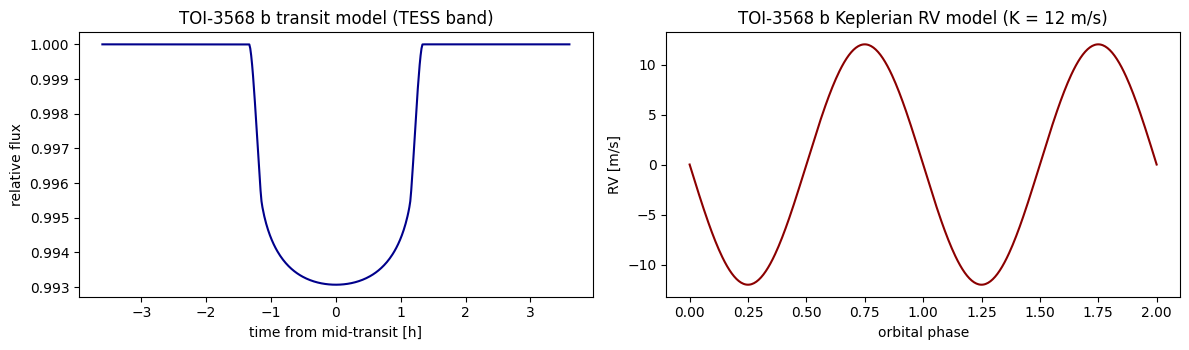

In [8]:
pl = {"per_000": 4.4178490108, "tc_000": 2459799.3828418534, "a_000": 13.5328445553,
      "inc_000": 89.5230363203, "rp_000": 0.0762261965, "u0_000": 0.3387, "u1_000": 0.3080,
      "esinw_000": 0.0, "ecosw_000": 0.0}

t_tr = np.linspace(pl["tc_000"] - 0.15, pl["tc_000"] + 0.15, 500)
flux_model = exoplanetlib.batman_transit_model(t_tr, pl)

# Keplerian RV model of the planet (m/s): rv_model takes the time of periastron,
# obtained from the transit time with timetrans_to_timeperi
ecc, w = 0.0, 90.0
tp = exoplanetlib.timetrans_to_timeperi(pl["tc_000"], pl["per_000"], ecc, w * np.pi / 180.0)
t_rv = np.linspace(pl["tc_000"], pl["tc_000"] + 2 * pl["per_000"], 400)
rv_model = exoplanetlib.rv_model(t_rv, pl["per_000"], tp, ecc, w * np.pi / 180.0, 12.02)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot((t_tr - pl["tc_000"]) * 24, flux_model, "-", color="darkblue")
axes[0].set_xlabel("time from mid-transit [h]"); axes[0].set_ylabel("relative flux")
axes[0].set_title("TOI-3568 b transit model (TESS band)")
axes[1].plot((t_rv - pl["tc_000"]) / pl["per_000"], rv_model, "-", color="darkred")
axes[1].set_xlabel("orbital phase"); axes[1].set_ylabel("RV [m/s]")
axes[1].set_title("TOI-3568 b Keplerian RV model (K = 12 m/s)")
plt.tight_layout(); plt.show()

## Next

Continue with **notebook 02** to fit the real TESS photometry of TOI-3568.

*Tip:* every analysis in these notebooks is also available as a command-line tool
(`transit_fit`, `rv_fit`, `transit_rv_fit`, `gls_analysis`, `system_params`, ... — run any of
them with `-h`).